In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import glob
import sys
sys.path.append("../scripts")
from TrackReconstruction_functions import *
from collections import Counter
import json
import os
import time

from tqdm import tqdm
import lmdb
import pickle

import torch
import torch.nn as nn
from torch.nn import Linear
import torch.nn.functional as F
from torch.utils.data import Dataset, Subset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool, TransformerConv
from torch_geometric.data import Data

from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

from joblib import Parallel, delayed

%matplotlib widget

/home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: libcudart.so.12: cannot open shared object file: No such file or directory
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSsb
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/torch_cluster/_

In [2]:
# Check for CUDA (NVIDIA) or MPS (Apple)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

scale_factor_bkg = None  # Initialize it globally or at the top
mapped_dataset=False # don't change this!
df_merged = pd.DataFrame()
mode = "GraphTransformer" # Graph Transformer Network

NVIDIA GeForce RTX 2060
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB
Using device: cuda


In [ ]:

# Will convert the graphs in to a lmdb database for faster loading of data
def MakeLMBD(file_paths, data_sample):

    lmdb_path = f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/GNN_files/GNN_{data_sample}_events.lmdb"
    meta_file = f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/GNN_files/GNN_{data_sample}_meta.json"
    
    # lmdb_path = f"GNN_{data_sample}_events_test.lmdb"
    # meta_file = f"GNN_{data_sample}_meta_test.json"
    
    subtype_counts = Counter()
    
    # If we have the file already then we dont need to run again. 
    if os.path.exists(lmdb_path):
        print("GNN LMDB files exist, so returning...")
        return
    
    env = lmdb.open(lmdb_path, map_size=1e12)  # adjust if needed
    idx = 0

    with env.begin(write=True) as txn:
        for file_path in file_paths:
            shard = torch.load(file_path, map_location="cpu")

            for graph in tqdm(shard):

                key = f"{idx:09d}".encode()
                value = pickle.dumps(graph)

                txn.put(key, value)
                idx += 1
                
                subtype = int(graph.subType.item())
                subtype_counts.update([subtype])

        
        # Save the metadata too
        print(f"Saving metadata to {meta_file}...")
        print(dict(subtype_counts))
        with open(meta_file, 'w') as f:
            json.dump({
                'subtype_counts': dict(subtype_counts)
            }, f)

    env.close()
    print(f"Stored {idx} events")

MakeLMBD(sorted(glob.glob("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//GNN_files/ATPC_GNN_chunk_train_*.pt")), "Train")
MakeLMBD(sorted(glob.glob("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//GNN_files/ATPC_GNN_chunk_val_*.pt")),   "Validation")
MakeLMBD(sorted(glob.glob("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//GNN_files/ATPC_GNN_chunk_test_*.pt")),  "Test")

/tmp/ipykernel_1434177/1439337567.py:17: DeprecationWarning: an integer is required (got type float).  Implicit conversion to integers using __int__ is deprecated, and may be removed in a future version of Python.
  env = lmdb.open(lmdb_path, map_size=1e12)  # adjust if needed
100%|██████████| 22648/22648 [00:05<00:00, 3802.00it/s]


In [ ]:
class LMDBEventDataset(Dataset):
    def __init__(self, lmdb_path, data_sample, one_vs_all=False):
        self.env = lmdb.open(lmdb_path, readonly=True, lock=False)
        self.one_vs_all = one_vs_all

        # Load in the metadata
        # meta_file = f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//GNN_files/GNN_{data_sample}_meta.json"
        meta_file = f"GNN_{data_sample}_meta_test.json"
        
        print(f"Loading metadata from cache: {meta_file}")
        with open(meta_file, 'r') as f:
            cache_data = json.load(f)
            raw_counts = cache_data['subtype_counts']
            self.subtype_counts = Counter({int(k): v for k, v in raw_counts.items()})
            
        print("The ova is set to ", self.one_vs_all)
        self.print_scale_factors(data_sample)

        with self.env.begin() as txn:
            self.length = txn.stat()['entries']

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        with self.env.begin() as txn:
            key = f"{idx:09d}".encode()
            graph = pickle.loads(txn.get(key))
            
            # If one vs all mode, then we remap the data, else leave it alone as its mapped correctly
            sub_type = int(graph.subType)
            
            if self.one_vs_all:
                new_y = self.multi_map.get(sub_type, 0)
                graph.y = torch.tensor([new_y], dtype=torch.long)

        return graph
        
    def print_scale_factors(self, data_sample):
        sig = self.subtype_counts[0]
        bi  = self.subtype_counts[1]
        tl  = self.subtype_counts[2]
        sn  = self.subtype_counts[3]
        total_bkg = bi + tl + sn

        print(f"\n--- {data_sample} Dataset Summary ---")
        print(f"Signal (0nubb): {sig}")
        print(f"Background: {total_bkg}")
        print(f"Thalium: {tl}")
        print(f"Bismuth: {bi}")
        print(f"Single: {sn}")


one_vs_all = False
train_dataset = LMDBEventDataset("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//GNN_files/GNN_Train_events.lmdb", "Train", one_vs_all)
val_dataset   = LMDBEventDataset("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//GNN_files/GNN_Validation_events.lmdb", "Validation", one_vs_all)
test_dataset  = LMDBEventDataset("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//GNN_files/GNN_Test_events.lmdb", "Test", one_vs_all)

# train_dataset = LMDBEventDataset("GNN_Train_events_test.lmdb", "Train", one_vs_all)
# val_dataset   = LMDBEventDataset("GNN_Validation_events_test.lmdb", "Validation", one_vs_all)
# test_dataset  = LMDBEventDataset("GNN_Test_events_test.lmdb", "Test", one_vs_all)


Loading metadata from cache: GNN_Train_meta_test.json
The ova is set to  False

--- Train Dataset Summary ---
Signal (0nubb): 55394
Background: 170635
Thalium: 54105
Bismuth: 60023
Single: 56507
Loading metadata from cache: GNN_Validation_meta_test.json
The ova is set to  False

--- Validation Dataset Summary ---
Signal (0nubb): 15828
Background: 48757
Thalium: 15459
Bismuth: 17151
Single: 16147
Loading metadata from cache: GNN_Test_meta_test.json
The ova is set to  False

--- Test Dataset Summary ---
Signal (0nubb): 7914
Background: 24383
Thalium: 7730
Bismuth: 8579
Single: 8074


In [ ]:
BATCH_SIZE=1000
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=15)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=15)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=15)

In [ ]:
# Define the GNN
class GATNet(nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes, heads=4):
        super().__init__()

        self.conv1 = GATConv(num_node_features, hidden_channels, heads=heads, concat=False) # concat False keeps hidden_channels fixed
        self.conv2 = GATConv(hidden_channels,   hidden_channels, heads=heads, concat=False)
        self.conv3 = GATConv(hidden_channels,   hidden_channels, heads=1,     concat=False)
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.elu(self.conv1(x, edge_index))
        x = F.elu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)

        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x
    
class GATNetEdge(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes, edge_dim, heads=4):
        super().__init__()

        self.conv1 = GATConv( num_node_features, hidden_channels, heads=heads, concat=False, edge_dim=edge_dim)
        self.conv2 = GATConv( hidden_channels,   hidden_channels, heads=heads, concat=False, edge_dim=edge_dim)
        self.conv3 = GATConv( hidden_channels,   hidden_channels, heads=1,     concat=False, edge_dim=edge_dim)
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_attr = getattr(data, 'edge_attr', None)
        x = F.elu(self.conv1(x, edge_index, edge_attr))
        x = F.elu(self.conv2(x, edge_index, edge_attr))
        x = self.conv3(x, edge_index, edge_attr)

        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x
    
class EventTransformerConv(torch.nn.Module):
    def __init__(self, hidden_channels, num_classes, num_node_features, edge_dim):
        super().__init__()
        self.conv1 = TransformerConv(num_node_features, hidden_channels, edge_dim=edge_dim)
        self.conv2 = TransformerConv(hidden_channels, hidden_channels, edge_dim=edge_dim)
        self.conv3 = TransformerConv(hidden_channels, hidden_channels, edge_dim=edge_dim)
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_attr = getattr(data, 'edge_attr', None)
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = self.conv3(x, edge_index, edge_attr)

        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x

In [ ]:
# Dervive weights based on inverse frequency
# Total / (Num_Classes * Class_Count)
# This method boosts signal and scales background down simultaniously
# average weight will remain 1
# Grab counts from the dataset object
sig = train_dataset.subtype_counts[0]
bi  = train_dataset.subtype_counts[1]
tl  = train_dataset.subtype_counts[2]
sn  = train_dataset.subtype_counts[3]
total_bkg = bi + tl + sn

# Calculate the raw factors
sf_bkg    = sig / total_bkg if total_bkg > 0 else 1.0
sf_bi     = sig / bi if bi > 0 else 1.0
sf_tl     = sig / tl if tl > 0 else 1.0
sf_single = sig / sn if sn > 0 else 1.0

total = total_bkg + sig

if one_vs_all:
    num_classes_train = 4
    extension = "ova"
    # Order: [Bi, Tl, Single, 0nubb]
    weight_bi = total / (num_classes_train * bi)
    weight_tl = total / (num_classes_train * tl)
    weight_single = total / (num_classes_train * sn)
    weight_signal = total / (num_classes_train * sig)

    train_weights = torch.tensor([weight_bi, weight_tl, weight_single, weight_signal]).to(device)
    print("Bi, Tl, Single, 0nubb")
    print(train_weights)
else:
    num_classes_train = 2
    extension = "binary"
    # Order: [Background, Signal]
    
    weight_bkg = total / (num_classes_train * total_bkg)
    weight_signal = total / (num_classes_train * sig)
    train_weights = torch.tensor([weight_bkg, weight_signal]).to(device)
    print("Background, Signal")
    print(train_weights)



Background, Signal
tensor([0.6623, 2.0402], device='cuda:0')


In [ ]:
# mode = "GAT" # Graph Attention Network
mode = "GraphTransformer" # Graph Transformer Network


# Define your ML models here
if mode == "GAT":
    model = GATNetEdge(hidden_channels=64, num_classes=num_classes_train, edge_dim=2, num_node_features = 7).to(device) # GAT + Edge Features
elif (mode == "GraphTransformer"):
    model = EventTransformerConv(hidden_channels=64, num_classes=num_classes_train, num_node_features=7, edge_dim=2).to(device) # Transformer model
else:
    print("Unknown ML network specified.")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) 
criterion = nn.CrossEntropyLoss(weight=train_weights)

total_batches = len(train_loader)
report_interval = max(1, total_batches // 5) # report every 20% batch processed
print("total batches", total_batches, "| report_interval", report_interval)

min_epoch = 0
last_epoch=0
history_df = pd.DataFrame()
best_val_loss=1e20

VERSION = 1

load_state = False
if (load_state):
    history_df = pd.read_csv(f"../GNN_files/GNN_{mode}_{extension}_train_history_v{VERSION}_all.csv")
    print("Loading Model State from file!")
    display(history_df)
    
    last_epoch = int(max(history_df.epoch)) # Carry on from the last epoch
    checkpoint = torch.load(f'../GNN_files/GNN_v{VERSION}_epoch{last_epoch}.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    min_epoch     = checkpoint['epoch']+1
    best_val_loss = checkpoint['loss']

# ---------------------------------------------------------------------------------------------------
EPOCHS = 2

for epoch in range(min_epoch, min_epoch+EPOCHS):
    print("Running Epoch ", epoch)
    t0 = time.time()

    # -------- training --------
    # Put the model in training mode, gradients will be computed
    model.train() 
    train_loss = 0.0 # Sum the loss over all batches, then average it

    # Loop over training batches
    for i, data in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()            # Clear old features
        logits = model(data)             # Data flows through the network, the output is called logits (raw scores not probabilities) -- forward pass
        loss = criterion(logits, data.y) # Compares the predictions (logits) with the true labels (yb)
        loss.backward()                  # Computes the gradients of the loss (stored in param.grad for every model param)
        optimizer.step()                 # Uses the gradients to update the weights. Depends on the optimizer e.g. SGD, Adam etc -- this is the learning step
        train_loss += loss.item() * data.num_graphs # Accumulates the total loss. loss.item() returns the loss for this batch. So multiply by batch size data.num_graphs 

        # Print every 10%
        if (i + 1) % report_interval == 0:
            percent_done = (i + 1) / total_batches * 100
            print(f"Progress Epoch {epoch}: {percent_done:.0f}% ({i + 1}/{total_batches} batches)")
            

    train_loss /= len(train_loader.dataset) # Average the training loss over the total dataset

    # -------- validation --------
    model.eval() # Disables dropout, freezes batchnorm statistics, ensures deterministic behaviour
    all_preds = []
    all_probs = []
    all_labels = []
    val_loss = 0.0

    with torch.no_grad(): # Disables gradient tracking (saves memory, speeds up evalulation, prevents accidental backpropagation)
        for data in val_loader:
            data = data.to(device) # Move the whole graph batch to GPU
            
            logits = model(data)
            loss = criterion(logits, data.y)
            val_loss += loss.item() * data.num_graphs
            
            probs = torch.softmax(logits, dim=1) # convert logits to probs, normalize to 1 
            preds = logits.argmax(dim=1)         # Return index with highest logit, class pred 0 or 1
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy()) # logits of signal column
            all_labels.extend(data.y.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    
    # Saving the model 
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': val_loss,
    }
    
    torch.save(checkpoint, f'../GNN_files/GNN_{mode}_{extension}_v{VERSION}_all.pt')

    if val_loss < best_val_loss:
        print("Model improved! Saving...")
        best_val_loss = val_loss
        
    AUC  = roc_auc_score(all_labels, all_probs)
    f1   = f1_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds)
    
    t1 = time.time()
    epoch_time = (t1 - t0)/60.
    print("Epoch time was:", epoch_time, "m")
    
    # Saving the information from the training
    metrics = {
        'epoch': epoch,
        'epoch_time': float(epoch_time),
        'train_loss': float(train_loss),
        'val_loss': float(val_loss),
        'val_f1': float(f1),
        'val_prec': float(prec),
        'val_rec': float(rec),
        'val_auc':float(AUC)
        
    }
    print(metrics)
    
    try:
        history_df = pd.read_csv(f"../GNN_files/GNN_{mode}_{extension}_train_history_v{VERSION}_all.csv")
    except:
        history_df = pd.DataFrame()
        
    history_df_current = pd.DataFrame([metrics])
    history_df = pd.concat( [history_df, history_df_current])
    history_df.to_csv(f'../GNN_files/GNN_{mode}_{extension}_train_history_v{VERSION}_all.csv', index=False)
    
    print(f"Epoch {epoch+1}/{min_epoch+EPOCHS} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f} | Val AUC: {AUC:.6f}")
    last_epoch=epoch

display(history_df)

total batches 227 | report_interval 45
Running Epoch  0
Progress Epoch 0: 20% (45/227 batches)
Progress Epoch 0: 40% (90/227 batches)
Progress Epoch 0: 59% (135/227 batches)
Progress Epoch 0: 79% (180/227 batches)
Progress Epoch 0: 99% (225/227 batches)
Model improved! Saving...
Epoch time was: 0.2796757936477661 m
{'epoch': 0, 'epoch_time': 0.2796757936477661, 'train_loss': 0.4813036996559255, 'val_loss': 0.5083244269644687, 'val_f1': 0.6870828725067695, 'val_prec': 0.8667372269796979, 'val_rec': 0.5691180187010362, 'val_auc': 0.9261472276870735}
Epoch 1/2 | Train Loss: 0.481 | Val Loss: 0.508 | Val AUC: 0.926147
Running Epoch  1
Progress Epoch 1: 20% (45/227 batches)
Progress Epoch 1: 40% (90/227 batches)
Progress Epoch 1: 59% (135/227 batches)
Progress Epoch 1: 79% (180/227 batches)
Progress Epoch 1: 99% (225/227 batches)
Model improved! Saving...
Epoch time was: 0.27837600708007815 m
{'epoch': 1, 'epoch_time': 0.27837600708007815, 'train_loss': 0.3081064840080562, 'val_loss': 0.307

,epoch,epoch_time,train_loss,val_loss,val_f1,val_prec,val_rec,val_auc
0,0,0.264064,0.551710,0.418884,0.702515,0.605348,0.836839,0.904610
1,1,0.262902,0.398028,0.339608,0.734269,0.620114,0.899936,0.934208
2,0,0.098185,0.563199,0.439233,0.657895,0.526618,0.876354,0.895329
3,1,0.091671,0.411396,0.356017,0.723057,0.616352,0.874442,0.925419
4,0,0.735290,0.301161,0.237762,0.870706,0.865435,0.876042,0.970354
5,1,0.748108,0.206872,0.211425,0.880824,0.863041,0.899356,0.975432
6,0,0.364911,0.366500,0.259034,0.854342,0.847229,0.861574,0.962818
7,1,0.363810,0.223904,0.211634,0.863596,0.820077,0.911991,0.971911
8,0,0.279676,0.481304,0.508324,0.687083,0.866737,0.569118,0.926147
0,1,0.278376,0.308106,0.307720,0.836141,0.866970,0.807430,0.957085


In [10]:
# Load in the best model during training and the training history
# Define your ML models here
if mode == "GAT":
    model = GATNetEdge(hidden_channels=64, num_classes=num_classes_train, edge_dim=2, num_node_features = 7).to(device) # GAT + Edge Features
elif (mode == "GraphTransformer"):
    model = EventTransformerConv(hidden_channels=64, num_classes=num_classes_train, num_node_features=7, edge_dim=2).to(device) # Transformer model
else:
    print("Unknown ML network specified.")


history_df = pd.read_csv(f"../GNN_files/GNN_{mode}_{extension}_train_history_v{VERSION}_all.csv")
display(history_df)

last_epoch = int(max(history_df.epoch)) # Carry on from the last epoch

# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(weight=train_weights) # [background, signal]

checkpoint = torch.load(f'../GNN_files/GNN_{mode}_{extension}_v1_all.pt', map_location=device)

# 4. Restore the states
model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']


,epoch,epoch_time,train_loss,val_loss,val_f1,val_prec,val_rec,val_auc
0,0,0.264064,0.551710,0.418884,0.702515,0.605348,0.836839,0.904610
1,1,0.262902,0.398028,0.339608,0.734269,0.620114,0.899936,0.934208
2,0,0.098185,0.563199,0.439233,0.657895,0.526618,0.876354,0.895329
3,1,0.091671,0.411396,0.356017,0.723057,0.616352,0.874442,0.925419


In [32]:

class_names = ['0nubb', 'Bi', 'Tl', 'single']
def CalcModelMetrics(model, loader, name, device, one_vs_all):
    model.eval()
    all_preds, all_labels, all_probs, event_ids, subTypes = [], [], [], [], []

    with torch.no_grad():
        # Loops over in batches specified in dataloader, returns array of length of the batch size. 
        for data in loader:
            data = data.to(device)
            logits = model(data)
            probs = torch.softmax(logits, dim=1) # List of length batch size, N row for each classification category
            preds = logits.argmax(dim=1)         # Return index with highest logit
            
            if (one_vs_all):
                p_signal = probs[:, 3].cpu() # Get the signal column probs
            else:
                p_signal = probs[:, 1].cpu() # Get the signal column probs
            
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(p_signal.cpu().numpy())
            all_labels.extend(data.y.cpu().numpy())

            subTypes.extend(data.subType.cpu().numpy())
            event_ids.extend(data.event_id.cpu().numpy())

    # df_scores = pd.DataFrame({"event_id":event_ids, "y_score":y_score, "y_true":y_true, "subTypes" : subTypes})
    df_scores = pd.DataFrame({"event_id": event_ids, "y_score_raw": all_preds, "y_score": all_probs, "y_true": all_labels, "subTypes" : subTypes})
    
    mapping = {i: name for i, name in enumerate(class_names)}
    df_scores['subTypes'] = df_scores['subTypes'].map(mapping)
    
    fpr, tpr, _  = roc_curve(all_labels, all_probs)
    f1   = f1_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds)
    AUC  = auc(fpr, tpr)
    
    print(name, "|| F1:", round(f1,5), "| Precision",  round(prec,5), "| Recall", round(rec,5), "| AUC", round(AUC,5))

    return fpr, tpr, AUC, df_scores

fpr_tr,   tpr_tr,  auc_tr,   df_scores_tr  = CalcModelMetrics(model, train_loader, "Train     ", device, one_vs_all)
fpr_va,   tpr_va,  auc_va,   df_scores_va  = CalcModelMetrics(model, val_loader,   "Validation", device, one_vs_all)
fpr_tst,  tpr_tst, auc_tst,  df_scores_tst = CalcModelMetrics(model, test_loader,  "Test      ", device, one_vs_all)
df_scores_all = pd.concat([df_scores_tr, df_scores_va, df_scores_tst])
display(df_scores_all)

Train      || F1: 0.83745 | Precision 0.86821 | Recall 0.80881 | AUC 0.95916
Validation || F1: 0.83614 | Precision 0.86697 | Recall 0.80743 | AUC 0.95708
Test       || F1: 0.83939 | Precision 0.868 | Recall 0.81261 | AUC 0.95771


,event_id,y_score_raw,y_score,y_true,subTypes
0,31560000122,0,0.002926,0,Bi
1,22470845,0,0.009332,0,single
2,21735649,0,0.046214,0,single
3,2040001144,0,0.001945,0,Tl
4,2096001306,0,0.039830,0,Tl
...,...,...,...,...,...
32292,1170867,1,0.972171,1,0nubb
32293,4010000917,0,0.000266,0,Tl
32294,1183818,1,0.977462,1,0nubb
32295,4096000957,0,0.006740,0,Tl


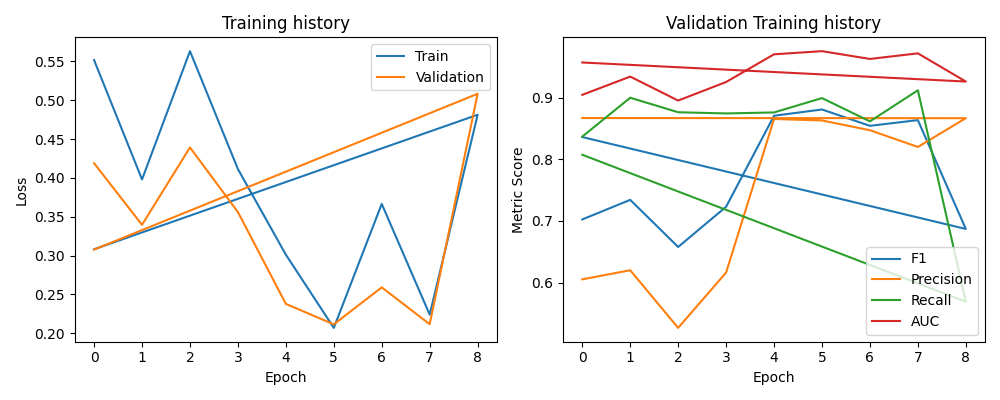

In [33]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

axs[0].plot(history_df.train_loss, label='Train')
axs[0].plot(history_df.val_loss, label='Validation')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].set_title('Training history')
plt.tight_layout()

axs[1].plot(history_df.val_f1, label='F1')
axs[1].plot(history_df.val_prec, label='Precision')
axs[1].plot(history_df.val_rec, label='Recall')
axs[1].plot(history_df.val_auc, label='AUC')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Metric Score')
axs[1].legend()
axs[1].set_title('Validation Training history')
plt.tight_layout()

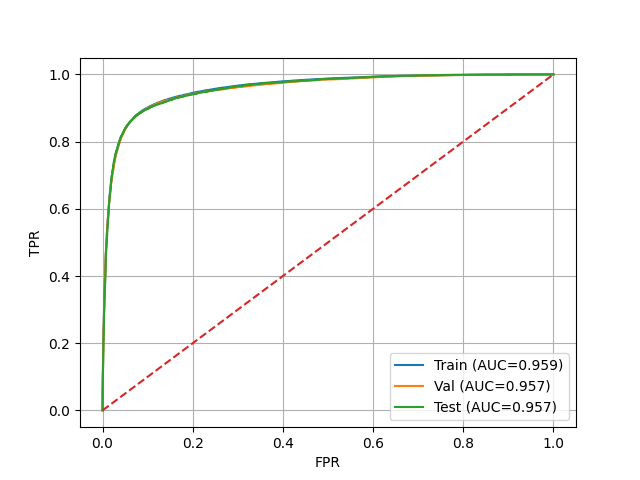

Val AUC: 0.957 


In [34]:
plt.figure()
plt.plot(fpr_tr, tpr_tr, label=f"Train (AUC={auc_tr:.3f})")
plt.plot(fpr_va, tpr_va, label=f"Val (AUC={auc_va:.3f})")
plt.plot(fpr_tst, tpr_tst, label=f"Test (AUC={auc_va:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True)
plt.show()
print(f"Val AUC: {auc_va:.3f} ")


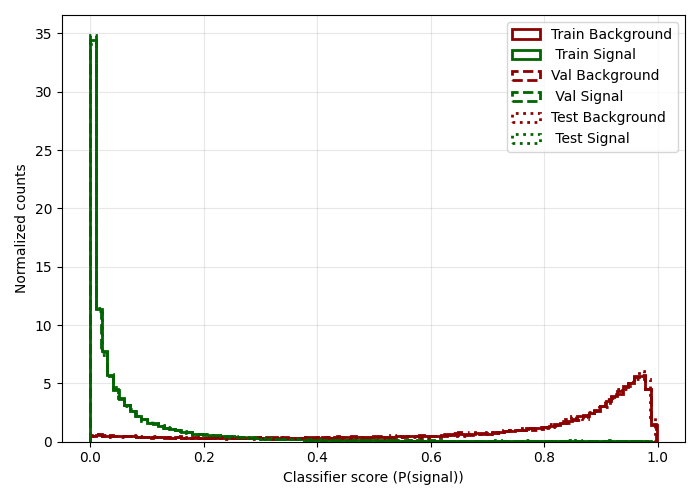

0.02978156086555225 0.2368833400727861


In [35]:
plt.figure(figsize=(7,5))

bins = 100


plt.hist(df_scores_tr[df_scores_tr.y_true == 1].y_score, bins=bins, density=True, histtype='step', linewidth=2, label='Train Background', linestyle = "-", color = "darkred")
plt.hist(df_scores_tr[df_scores_tr.y_true == 0].y_score, bins=bins, density=True, histtype='step', linewidth=2, label=' Train Signal',    linestyle = "-", color = "darkgreen")

plt.hist(df_scores_va[df_scores_va.y_true == 1].y_score, bins=bins, density=True, histtype='step', linewidth=2, label='Val Background', linestyle = "--", color = "darkred")
plt.hist(df_scores_va[df_scores_va.y_true == 0].y_score, bins=bins, density=True, histtype='step', linewidth=2, label=' Val Signal',    linestyle = "--", color = "darkgreen")

plt.hist(df_scores_tst[df_scores_tst.y_true == 1].y_score, bins=bins, density=True, histtype='step', linewidth=2, label='Test Background', linestyle = ":", color = "darkred")
plt.hist(df_scores_tst[df_scores_tst.y_true == 0].y_score, bins=bins, density=True, histtype='step', linewidth=2, label=' Test Signal',    linestyle = ":", color = "darkgreen")


plt.xlabel("Classifier score (P(signal))")
plt.ylabel("Normalized counts")
plt.legend()
plt.grid(alpha=0.3)

# plt.semilogy()
plt.tight_layout()
plt.show()

cut = 0.6
signal_eff = len(df_scores_all[ (df_scores_all.y_true == 0) & (df_scores_all.y_score > cut)])/len(df_scores_all[ (df_scores_all.y_true == 0)])
bkg_rej = 1 - len(df_scores_all[ (df_scores_all.y_true == 1) & (df_scores_all.y_score > cut)])/len(df_scores_all[ (df_scores_all.y_true == 1)])
print(signal_eff, bkg_rej)

Cut =  0.955
Signal Eff:   0.19
Bkg Eff, Bkg Rej, Bkg Rej Fact
Tl ERej:      0.0005 0.9995 2089.03
Bi ERej:      0.0017 0.9983 583.35
single ERej:  0.0027 0.9973 377.23


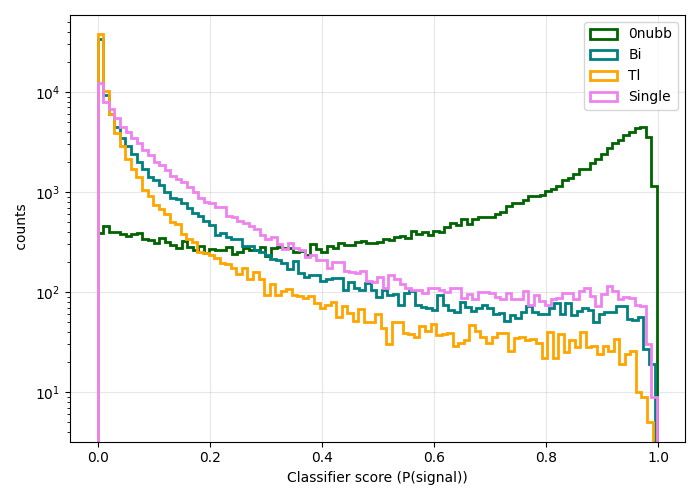

In [36]:
def CalcEfficiency(df, label, cut):
    num = len(df[ (df.subTypes == label) & (df.y_score > cut)])
    den = len(df[ (df.subTypes == label)])
    return num/den

cut = 0.955

print("Cut = ", cut)
print(f"Signal Eff:   {CalcEfficiency(df_scores_all, '0nubb', cut):.2f}")

print("Bkg Eff, Bkg Rej, Bkg Rej Fact")
tl_eff = CalcEfficiency(df_scores_all, "Tl", cut)
print(f"Tl ERej:      {tl_eff:.4f} {1-tl_eff:.4f} {1/tl_eff:.2f}")

bi_eff = CalcEfficiency(df_scores_all, "Bi", cut)
print(f"Bi ERej:      {bi_eff:.4f} {1-bi_eff:.4f} {1/bi_eff:.2f}")

s_eff = CalcEfficiency(df_scores_all, "single", cut)
print(f"single ERej:  {s_eff:.4f} {1-s_eff:.4f} {1/s_eff:.2f}")

plt.figure(figsize=(7,5))

bins = 100

plt.hist(df_scores_all[ (df_scores_all.subTypes == "0nubb")].y_score,  bins=bins, density=False, histtype='step', linewidth=2, label='0nubb',  color = "darkgreen");
plt.hist(df_scores_all[ (df_scores_all.subTypes == "Bi")].y_score,     bins=bins, density=False, histtype='step', linewidth=2, label='Bi',     color = "Teal");
plt.hist(df_scores_all[ (df_scores_all.subTypes == "Tl")].y_score,     bins=bins, density=False, histtype='step', linewidth=2, label='Tl',     color = "Orange");
plt.hist(df_scores_all[ (df_scores_all.subTypes == "single")].y_score, bins=bins, density=False, histtype='step', linewidth=2, label='Single', color = "violet");


plt.xlabel("Classifier score (P(signal))")
plt.ylabel(" counts")
plt.legend()
plt.grid(alpha=0.3)

plt.semilogy()
plt.tight_layout()
plt.show()

In [ ]:
df_out = df_scores_all.copy()
df_out['subType'] = df_out['subTypes'].replace({'0nubb': 'ATPC_0nubb', 'Bi': 'ATPC_Bi_ion', 'Tl': 'ATPC_Tl_ion', 'single': 'ATPC_single'})
df_out = df_out[["event_id", "subType", "y_score"]]
df_out = df_out[df_out.y_score > cut]
display(df_out)


# df_out[["event_id", "subType"]].to_csv("../eventlists/ATPC_1bar_5percent_GNN.csv", index=False)

# print(len(df_out[df_out.subType == "ATPC_0nubb"]))
# print(len(df_out[df_out.subType == "ATPC_Bi_ion"]))
# print(len(df_out[df_out.subType == "ATPC_Tl_ion"]))
# print(len(df_out[df_out.subType == "ATPC_single"]))


,event_id,subType,y_score
47,94185508,ATPC_single,0.955162
257,94207140,ATPC_single,0.955422
317,94227527,ATPC_single,0.971623
319,94227550,ATPC_single,0.962560
429,94248328,ATPC_single,0.969830
...,...,...,...
314581,926305,ATPC_0nubb,0.967412
314582,926312,ATPC_0nubb,0.967026
314681,30180000078,ATPC_Bi_ion,0.983852
315467,2610001331,ATPC_Tl_ion,0.964702


In [ ]:
# Load in the MC true for all events
def process_single_file(f):
    """Worker function for one file"""
    try:
        part = pd.read_hdf(f, "MC/particles", columns=["event_id","primary","particle_id", "initial_z", "final_z", "kin_energy"])
        return part[part.primary == 1]
    except Exception as e:
        print(f"Error in {f}: {e}")
        return None

def LoadFilesParallel(filepath):
    files = glob.glob(filepath)
    
    # n_jobs=-1 uses all available cores (all 60)
    # prefer="threads" is good for I/O, but "processes" is better for pandas filtering
    results = Parallel(n_jobs=-1, verbose=10)( delayed(process_single_file)(f) for f in files)
    
    # Filter out None results if any files failed to load
    results = [res for res in results if res is not None]
    
    return pd.concat(results)

category_to_study="ATPC_0nubb"
# category_to_study="ATPC_single"

nubb_1bar_highstats = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/{category_to_study}/1bar/nexus/*.h5")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done  93 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done 137 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done 185 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 237 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done 264 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done 293 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done 322 tasks      | elapsed:   10.8s
[Parallel(n_jobs=-1)]: Done 353 tasks      | elapsed:  

In [ ]:
# Function gives the lowest energy electron as the final position
# Then normalizes so its range is from 0->1
def GetBlob2Pos(df, shift):
    
    # Order by event id and reset the indexes
    df = df.sort_values("event_id")
    df = df.reset_index(drop=True)
    
    idx = df.groupby('event_id')['kin_energy'].idxmin()
    lowest_energy_particles = df.loc[idx]
    
    lowest_energy_particles["norm_zi"] = (lowest_energy_particles.initial_z + shift)/ (shift*2.0)
    lowest_energy_particles["norm_zf"] = (lowest_energy_particles.final_z + shift)/ (shift*2.0)
    
    return lowest_energy_particles

# Adds the asymetry as a df column
def CalcAsymmetry(df, category_to_study):
    
    if (category_to_study != "ATPC_0nubb"):
        return df
    
    # 1. Pivot or Filter to get energies per event
    # We use a pivot to align particle_id 1 and 2 side-by-side for every event_id
    energies = df.pivot(index='event_id', columns='particle_id', values='kin_energy')
    
    asymmetry = np.abs((energies[1] - energies[2]) / (energies[1] + energies[2]))

    df['A'] = df['event_id'].map(asymmetry)
    
    return df

nubb_1bar_highstats_norm = nubb_1bar_highstats

if (category_to_study == "ATPC_0nubb"):
    nubb_1bar_highstats_norm  = CalcAsymmetry(nubb_1bar_highstats_norm, category_to_study)

nubb_1bar_highstats_norm  = GetBlob2Pos(nubb_1bar_highstats_norm,  3100.)

display(nubb_1bar_highstats_norm)

,event_id,primary,particle_id,initial_z,final_z,kin_energy,A,norm_zi,norm_zf
1,30801,1,1,-793.338562,-879.155945,0.330876,0.730758,0.372042,0.358201
3,30803,1,1,-2582.087646,-2568.735596,0.101071,0.917756,0.083534,0.085688
4,30805,1,2,-496.527008,-304.158630,0.960754,0.218210,0.419915,0.450942
7,30806,1,1,222.822800,250.438065,0.511793,0.583541,0.535939,0.540393
8,30808,1,2,2116.041016,2170.171387,0.423556,0.655342,0.841297,0.850028
...,...,...,...,...,...,...,...,...,...
1551720,2450204,1,2,-1961.416626,-1999.545532,0.882019,0.282278,0.183642,0.177493
1551723,2450205,1,2,1022.709717,1261.817139,0.937353,0.237251,0.664953,0.703519
1551724,2450206,1,1,1526.121948,1511.392578,0.225970,0.816123,0.746149,0.743773
1551727,2450207,1,1,-100.120369,52.205341,1.078914,0.122060,0.483852,0.508420


In [ ]:
selected_events = df_out[df_out.subType == category_to_study].event_id.unique()

nubb_1bar_highstats_selected = nubb_1bar_highstats_norm[nubb_1bar_highstats_norm.event_id.isin(selected_events)]

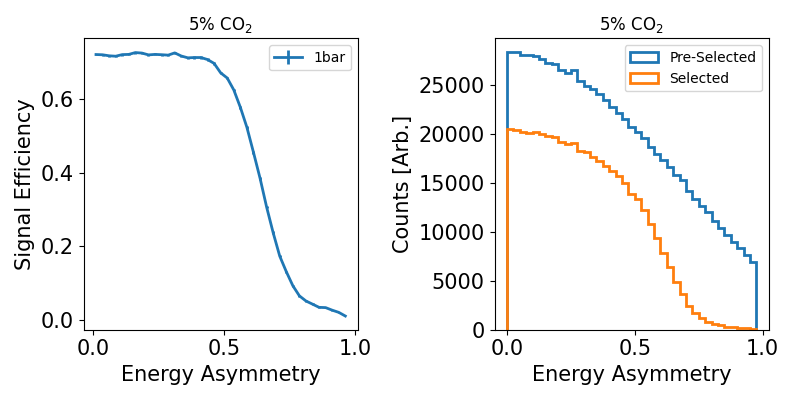

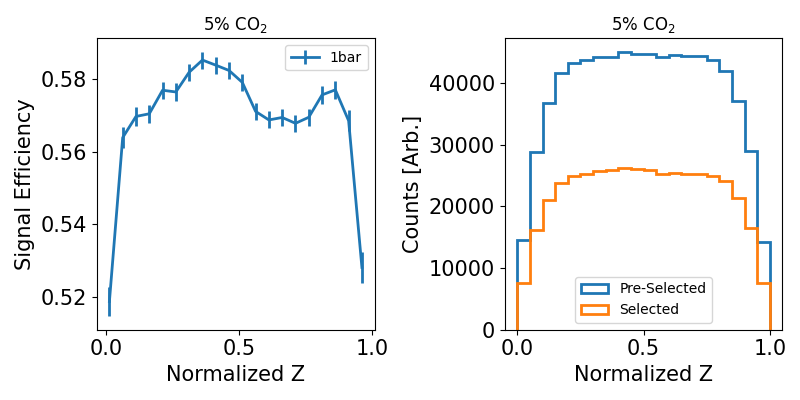

In [ ]:
def CalcEfficiency(n, N, correct):
    efficiency = n/N
    
    # This corrects by applying energy resolution cut
    if correct:
        efficiency = 0.82*efficiency
    
    error=np.sqrt( (efficiency/N) * (1-efficiency)  )
    return efficiency, error

def GetHistogram(df_true, df_true_selected, var, bins):
        
    # Distribution before cuts
    n_gen, bins = np.histogram( df_true[f"{var}"],      bins = bins);
    n_sel, _    = np.histogram( df_true_selected[f"{var}"], bins = bins);
    efficiency, error = CalcEfficiency(n_sel, n_gen, False)
    
    bin_centers = bins+0.025/2.0
    bin_centers = bin_centers[:-1]
    
    return efficiency, error, bin_centers


if (category_to_study == "ATPC_0nubb"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
    eff,  err,  bins  = GetHistogram(nubb_1bar_highstats_norm,  nubb_1bar_highstats_selected,  "A", np.arange(0,1,0.025))
    ax1.errorbar(bins, eff, yerr=err, linewidth = 2, label = "1bar")
    ax1.set_xlabel("Energy Asymmetry", fontsize=15);
    ax1.set_ylabel("Signal Efficiency", fontsize=15);
    ax1.tick_params(axis='both', labelsize=15)
    ax1.legend()
    ax1.set_title(r"5% CO$_2$")
    plt.tight_layout()
    
    ax2.hist(nubb_1bar_highstats_norm.A, bins = np.arange(0,1,0.025), linewidth = 2, histtype = "step", density=False, label = "Pre-Selected")
    ax2.hist(nubb_1bar_highstats_selected.A, bins = np.arange(0,1,0.025), linewidth = 2, histtype = "step", density=False, label = "Selected")
    ax2.set_xlabel("Energy Asymmetry", fontsize=15);
    ax2.set_ylabel("Counts [Arb.]", fontsize=15);
    ax2.tick_params(axis='both', labelsize=15)
    ax2.legend()
    ax2.set_title(r"5% CO$_2$")
    plt.tight_layout()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
eff,  err,  bins  = GetHistogram(nubb_1bar_highstats_norm,  nubb_1bar_highstats_selected,  "norm_zf", np.arange(0,1.05,0.05))
ax1.errorbar(bins, eff, yerr=err, linewidth = 2, label = "1bar")
ax1.set_xlabel("Normalized Z", fontsize=15);
ax1.set_ylabel("Signal Efficiency", fontsize=15);
ax1.tick_params(axis='both', labelsize=15)
ax1.legend()
ax1.set_title(r"5% CO$_2$")
plt.tight_layout()

ax2.hist(nubb_1bar_highstats_norm.norm_zf, bins = np.arange(0,1.05,0.05), linewidth = 2, histtype = "step", density=False, label = "Pre-Selected")
ax2.hist(nubb_1bar_highstats_selected.norm_zf, bins = np.arange(0,1.05,0.05), linewidth = 2, histtype = "step", density=False, label = "Selected")
ax2.set_xlabel("Normalized Z", fontsize=15);
ax2.set_ylabel("Counts [Arb.]", fontsize=15);
ax2.tick_params(axis='both', labelsize=15)
ax2.legend()
ax2.set_title(r"5% CO$_2$")
plt.tight_layout()